**Imports & set-up**

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# **1. Data Cleaning**

In [6]:
df = pd.read_csv("../../data/star-galaxy-quasar.csv", sep=",", skiprows=1)

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

if "class" in df.columns:
    print("\nClass distribution:")
    print(df["class"].value_counts())

display(df.head())


Shape: (10000, 10)

Data types:
objid         int64
ra          float64
dec         float64
u           float64
g           float64
r           float64
i           float64
z           float64
class        object
redshift    float64
dtype: object

Missing values:
objid       0
ra          0
dec         0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64

Duplicate rows: 0

Class distribution:
class
GALAXY    8449
STAR       865
QSO        686
Name: count, dtype: int64


,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327
3,1237654670272102476,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,GALAXY,0.088111
4,1237651801233752148,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,GALAXY,0.079039


**Drop objid and class columns (df1)**

In [7]:
# Keep true labels aside only for evaluation
real_y = None
if "class" in df.columns:
    real_y = df["class"].copy()

## Drop identifier/ label columns
df1 = df.drop(columns=["objid", "class"], axis=1).copy()
df1.head()

,ra,dec,u,g,r,i,z,redshift
0,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934
1,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808
2,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327
3,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,0.088111
4,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,0.079039


**Feature Engineering**

In [8]:
## Compute color indices (differences between adjacent bands)
## - Often more discriminative than raw magnitudes (Add why from reading)
df1["u_g"] = df1["u"] - df1["g"]
df1["g_r"] = df1["g"] - df1["r"]
df1["r_i"] = df1["r"] - df1["i"]
df1["i_z"] = df1["i"] - df1["z"]

df1.head()

,ra,dec,u,g,r,i,z,redshift,u_g,g_r,r_i,i_z
0,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934,1.89183,0.97312,0.44642,0.33393
1,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808,1.74284,0.96594,0.53794,0.34925
2,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327,1.44872,0.85088,0.41556,0.32810
3,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,0.088111,1.97767,0.94814,0.45569,0.35529
4,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,0.079039,1.48383,0.68268,0.41322,0.19883


**Standardize the data (df2)**

In [9]:
scaler = StandardScaler()

# Store column names before scaling
column_names = df1.columns

df2 = scaler.fit_transform(df1)
df2 = pd.DataFrame(df2, columns=column_names)
display(df2.head())
df2.size

,ra,dec,u,g,r,i,z,redshift,u_g,g_r,r_i,i_z
0,-1.433938,-0.515361,0.034267,0.034965,0.033196,0.035976,0.037200,-0.293454,-0.007334,0.011071,-0.013851,-0.009447
1,-1.436229,0.265014,0.029765,0.031051,0.029143,0.031979,0.033299,-0.372305,-0.008821,0.011000,-0.013205,-0.009294
2,-1.432650,-0.435150,0.034326,0.036249,0.034885,0.037623,0.038806,-0.313394,-0.011757,0.009851,-0.014069,-0.009505
3,-1.435278,0.124261,0.035895,0.036292,0.034649,0.037297,0.038421,-0.304992,-0.006477,0.010822,-0.013786,-0.009234
4,-1.432856,0.248881,0.034007,0.035846,0.034950,0.037690,0.039204,-0.332371,-0.011407,0.008172,-0.014085,-0.010796


120000

# **2. Exploratory Data Analysis**

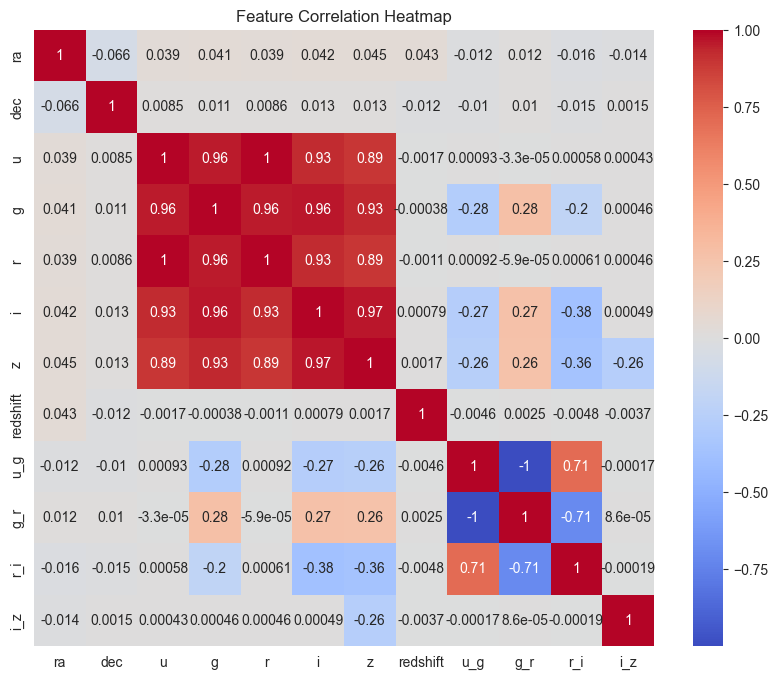

In [10]:
plt.figure(figsize=(10, 8))

corr = df2.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

This heatmap reveals 3 important patterns in the data. The photometric magnitudes (u, g, r, i, z) have very high correlations of 0.89-1.00, indicating high redundancy as they are measuring similar information (brightness). With high redundancy in such features, Principal Component Analysis (PCA) becomes especially useful in dimensionality reduction, such that we only consider the most prominent features in our analysis.

Engineered color index features show different correlation patterns compared to raw magnitudes, reflecting negative correlations with raw bands and a strong relationship among themselves (u_g vs g_r = -1). This indicates that they capture additional information useful for distinguishing objects.

On the other hand, spatial features (ra, dec, redshift) are mostly independent, showing near 0 correlation with photometric features, suggesting they contribute independent information.

/var/folders/32/q3tnvx250vscqz7f2nbpltvm0000gn/T/ipykernel_24280/3047215384.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df_plot.groupby("class", group_keys=False).apply(


<Axes: xlabel='ra', ylabel='dec'>

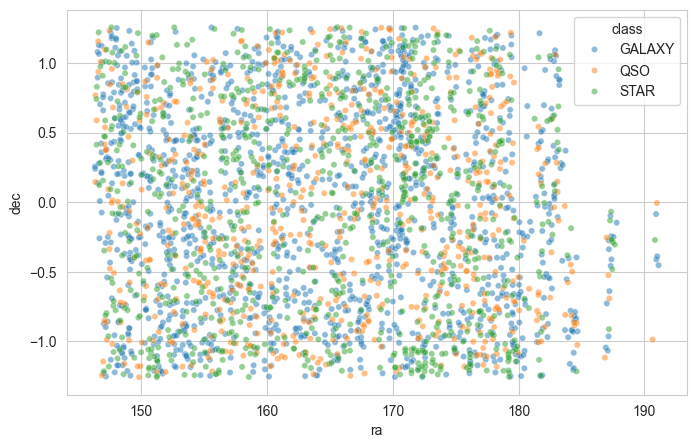

In [11]:
## Check significance of ra & dec
df_plot = df1.copy()
df_plot["class"] = real_y.values

sample_df = df_plot.groupby("class", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1500), random_state=42)
)
sns.scatterplot(data=sample_df, x="ra", y="dec",
                hue="class", alpha=0.5, s=20)

Spatial features such as right ascension and declination (i.e., astral object's position in sky) show low correlation with other variables in the correlation heatmap, indicating independence. However, visual analysis reveals no clear separation between classes based on these features, suggesting that spatial location does not significantly contribute to distinguishing object types (objects are scattered randomly).

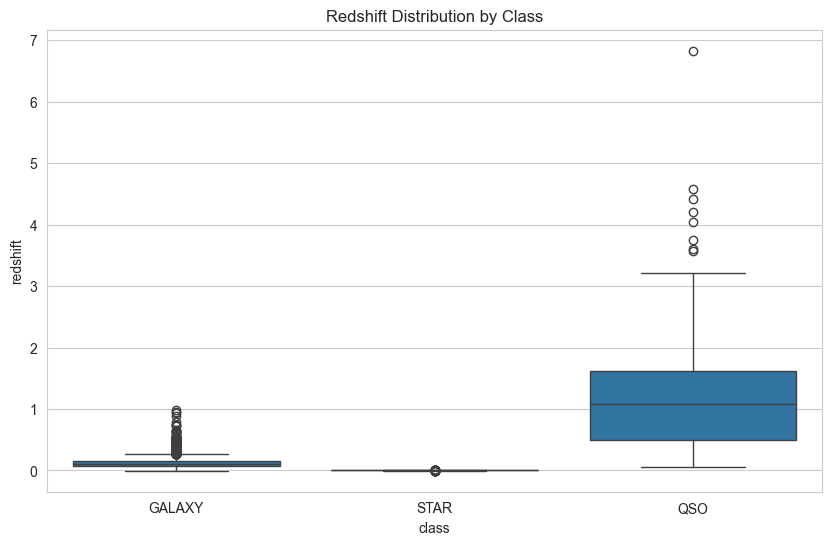

In [12]:
# Redshift boxplot by class

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x="class", y="redshift")
plt.title("Redshift Distribution by Class")
plt.show()

This redshift boxplot demonstrates strong separation between classes, with Quasars (QSO) exhibiting significantly higher and more variable redshift values compared to stars and galaxies. This indicates that redshift, related to distance relative to Earth, is a highly discriminative feature, especially in comparison to the aforementioned spatial features.

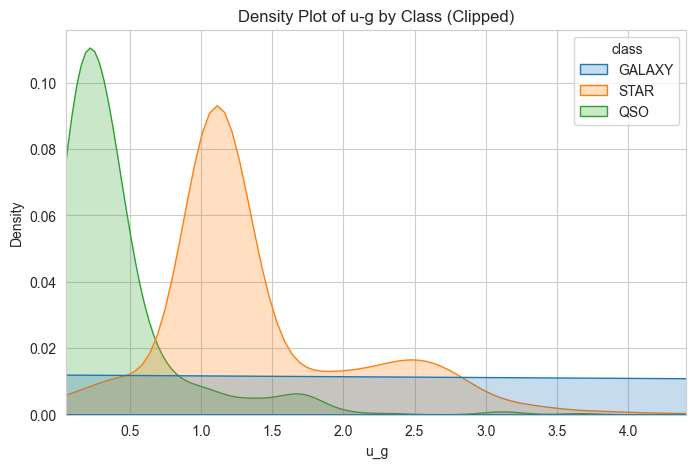

In [13]:
x_low, x_high = df_plot["u_g"].quantile([0.01, 0.99])

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_plot, x="u_g", hue="class", fill=True)
plt.xlim(x_low, x_high)
plt.title("Density Plot of u-g by Class (Clipped)")
plt.show()

This density plot of the u−g feature shows strong separation between classes. Quasars tend to have lower u−g values, while stars are concentrated at higher values, indicating that this feature is useful for distinguishing between these two classes. However, galaxies exhibit a broader distribution that overlaps with both, suggesting that u−g alone is insufficient for complete separation.

Other color features such as g-r show similar but weaker patterns and are therefore not further emphasised.

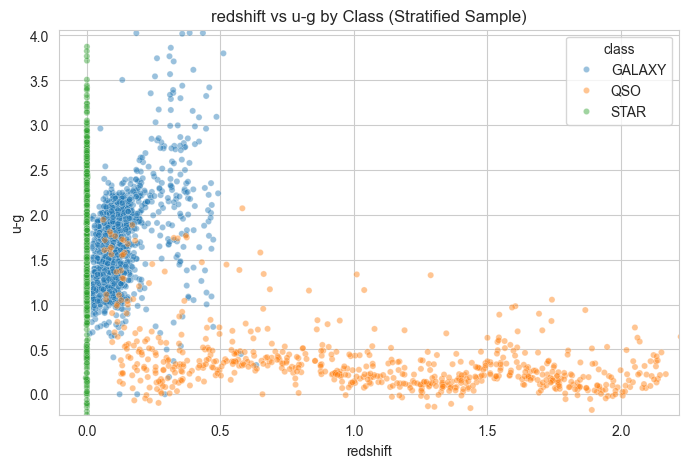

In [14]:
x_low, x_high = sample_df["redshift"].quantile([0.01, 0.99])
y_low, y_high = sample_df["u_g"].quantile([0.01, 0.99])

x_range = x_high - x_low
y_range = y_high - y_low

sns.scatterplot(
    data=sample_df,
    x="redshift",
    y="u_g",
    hue="class",
    alpha=0.45,
    s=20
)
plt.xlabel("redshift")
plt.ylabel("u-g")
plt.title("redshift vs u-g by Class (Stratified Sample)")
plt.xlim(x_low - 0.05*x_range, x_high + 0.05*x_range)
plt.ylim(y_low - 0.05*y_range, y_high + 0.05*y_range)
plt.show()

To further explore how redshift interacts with other features, a scatter plot of redshift versus u−g was analysed. The resulting graph reveals clear separation between classes along the redshift axis. Stars are concentrated near zero redshift, reflecting their proximity, while quasars extend to significantly higher redshift values. Galaxies occupy an intermediate range.

The u−g feature provides additional refinement within overlapping regions, but the primary separation is driven by redshift. This indicates that redshift is the most discriminative feature, while color indices contribute secondary information for clustering.

# **3. Principle Component Analysis**

*   PCA helps to visualise high-dimensional data by projecting it into lower dimensional spcae (e.g, 2D/ 3D graph)


*   All Principle Components are uncorrelated
* PC1 has the highest variance (most amt of info from the original dataset retained in PC1)

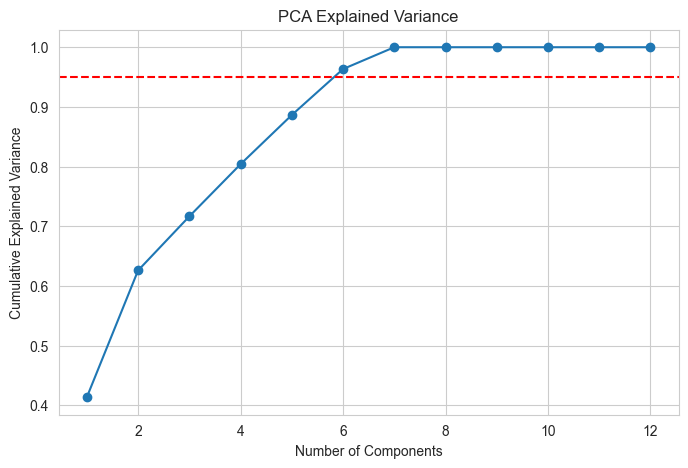

Components for 95% variance captured: 6


In [15]:
pca_full = PCA()
pca_full.fit(df2)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

### number of components for 95%
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print("Components for 95% variance captured:", n_components_95)

# Most of the dataset's info can be retained using ~6 Principle Components,
# indicating redundancy among current features

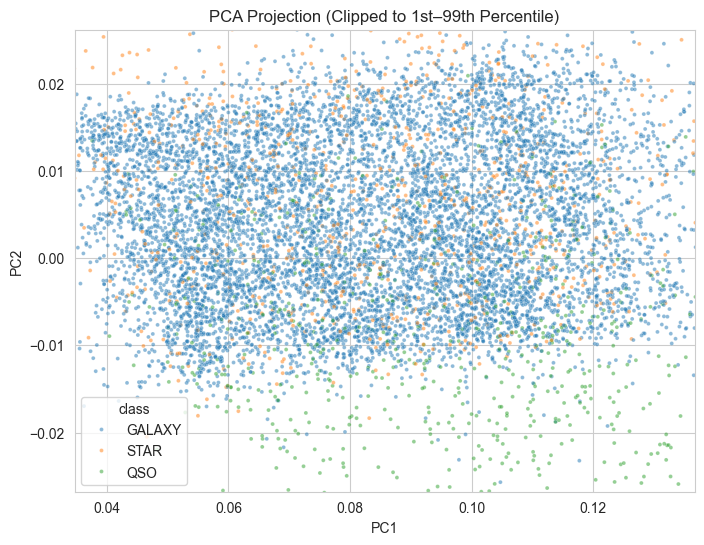

In [16]:
## Reduce high-dimensionality data (12 features) to 2 dimensions
# PC1 (most impt direction) & PC2 (second most impt)
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(df2)

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "class": real_y.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="class", alpha=0.5, s=8)

x_low, x_high = plot_df["PC1"].quantile([0.01, 0.99])
y_low, y_high = plot_df["PC2"].quantile([0.01, 0.99])

plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)

plt.title("PCA Projection (Clipped to 1st–99th Percentile)")
plt.show()

The PCA projection was visualised after clipping extreme values to the 1st-99th percentile to reduce distortion from outliers.

The resulting plot shows slight separation between classes, with quasars tending to occupy lower PC2 regions. Galaxies and stars are spread across the center and exhibit significant overlap, with galaxies being dominant.

However, overall the PCA projection onto the first 2 components shows significant overlap between classes, indicating that the data is not easily separable in lower dimensions. While PCA captures directions of maximum variance well, it does not prioritise class-discriminative directions. Hence, while 2 components are used for visualisation purposes, 6 components are still optimal for modelling to preserve most of the dataset's information. Additionally, the strong overlap suggests that clustering may be challenging and motivates the use of more flexible models.

In [17]:
## Show how impt each original feature is to each principal component/ how much they contribute to PC

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_full.components_))],
    index=column_names
)
display(loadings.head(10))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
ra,0.023875,0.002143,0.652301,0.173746,-0.062693,0.734689,0.006610,0.000095,2.434477e-15,-9.722067e-17,2.506008e-16,-3.583509e-15
dec,0.006924,-0.008581,-0.555204,-0.226114,0.538389,0.592078,0.008948,0.000116,3.360917e-15,-2.129146e-16,4.926256e-16,-4.276374e-15
u,0.413536,0.236830,-0.025828,0.058869,0.001380,-0.005902,0.096439,0.251679,-4.442271e-01,-2.474248e-01,-5.377594e-01,-3.851564e-01
g,0.441044,0.070679,-0.026846,0.063804,-0.000356,-0.007599,0.196621,0.054361,6.407815e-01,-5.491920e-01,1.983266e-01,-4.973852e-02
r,0.413533,0.236838,-0.025583,0.058972,0.001918,-0.006048,0.096483,-0.134247,-3.505501e-01,2.591077e-01,7.101869e-01,-2.168118e-01
i,0.443573,0.033507,-0.022271,0.050726,0.001762,-0.004772,-0.200146,-0.098051,-2.209000e-01,-8.006166e-02,-9.292605e-02,8.279555e-01
z,0.435863,0.033829,0.055854,-0.189307,-0.004404,-0.017893,-0.172872,-0.088821,4.287693e-01,6.595112e-01,-3.096924e-01,-1.307707e-01
redshift,0.000685,-0.004407,0.413282,0.131080,0.839953,-0.326292,0.002409,0.001593,4.095384e-14,3.875436e-16,3.425066e-15,-5.938663e-14
u_g,-0.157268,0.565389,0.007299,-0.026060,0.006060,0.006943,-0.374546,0.675607,1.282898e-01,7.145461e-02,1.553013e-01,1.112306e-01
g_r,0.157638,-0.565192,-0.008169,0.025755,-0.007923,-0.006443,0.374467,0.660596,-4.954373e-02,2.238750e-01,1.002639e-01,1.250379e-01


In [18]:
for i in range(3):  # first 3 PCs
    print(f"\nTop features for PC{i+1}:")
    print(loadings[f"PC{i+1}"].abs().sort_values(ascending=False).head(5))


Top features for PC1:
i    0.443573
g    0.441044
z    0.435863
u    0.413536
r    0.413533
Name: PC1, dtype: float64

Top features for PC2:
u_g    0.565389
g_r    0.565192
r_i    0.491244
r      0.236838
u      0.236830
Name: PC2, dtype: float64

Top features for PC3:
ra          0.652301
dec         0.555204
redshift    0.413282
i_z         0.299429
z           0.055854
Name: PC3, dtype: float64




*   **PC1: i, g, z, u, r → all high** (PC1 represents overall brightness/ magnitude since all photometric bands contribute similarly)
*   **PC2: u_g, g_r, r_i → highest** (PC2 captures color differences, proving feature engineering is useful)
* **PC3: ra, dec and redshift are dominant** (PC3 captures spatial + distance information)

